# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Smart Healthcare Appoitment Dataset](https://www.kaggle.com/datasets/sonalshinde123/smart-healthcare-patient-appointment-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.	

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import GradientBoostingClassifier

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('smart_hospital_appointment_dataset.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
0,PAT_10000,52,Male,Mumbai,19.6,Hypertension,Scheduled,Neurology,Headache,Low,...,43,7,2,3.0,0,8.6,869,413,1936.0,Completed
1,PAT_10001,21,Female,Mumbai,25.3,NaN,Scheduled,Neurology,Headache,Low,...,44,11,5,3.5,0,8.8,786,875,1356.6,No Show
2,PAT_10002,51,Female,Bangalore,21.9,NaN,Scheduled,Dermatology,Skin Allergy,Low,...,33,9,0,4.4,0,10.0,466,427,1108.8,No Show
3,PAT_10003,78,Female,Delhi,31.7,NaN,Walk-in,Orthopedics,Joint Pain,Low,...,59,13,3,4.1,0,8.1,921,401,1417.5,Completed
4,PAT_10004,62,Female,Mumbai,24.7,Hypertension,Scheduled,Ophthalmology,Eye Irritation,Low,...,42,4,0,3.5,0,8.9,152,216,746.9,Completed


## last Five row

In [4]:
df.tail()

,patient_id,age,gender,city,bmi,chronic_disease,appointment_type,department,symptoms,severity_level,...,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill,appointment_status
9995,PAT_19995,15,Male,Nagpur,17.2,NaN,Walk-in,Neurology,Headache,High,...,8,5,1,4.8,0,10.0,7218,11425,13643.0,Completed
9996,PAT_19996,70,Female,Pune,36.3,NaN,Walk-in,Cardiology,Chest Pain,Medium,...,19,0,0,3.1,0,10.0,4671,3558,6234.9,Completed
9997,PAT_19997,64,Female,Kolkata,27.3,Diabetes,Emergency,Ophthalmology,Eye Irritation,Low,...,47,8,3,4.6,1,9.2,189,276,879.0,Completed
9998,PAT_19998,21,Male,Hyderabad,27.0,Hypertension,Walk-in,Gastroenterology,Stomach Pain,High,...,12,11,7,3.1,0,10.0,8044,7855,11531.1,Completed
9999,PAT_19999,82,Male,Jaipur,15.4,Hypertension,Scheduled,General Medicine,Fever,Medium,...,24,2,0,5.0,0,10.0,2214,2843,5685.0,No Show


## Shape of our dataset

In [5]:
df.shape

(10000, 26)

## List out all columns

In [6]:
df.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'chronic_disease',
       'appointment_type', 'department', 'symptoms', 'severity_level',
       'doctor_experience_years', 'consultation_fee', 'insurance',
       'appointment_day', 'appointment_month', 'booking_to_appointment_days',
       'waiting_time_minutes', 'previous_appointments',
       'missed_previous_appointments', 'hospital_rating', 'emergency_case',
       'patient_satisfaction_score', 'medicine_cost', 'test_cost',
       'total_bill', 'appointment_status'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

patient_id                       object
age                               int64
gender                           object
city                             object
bmi                             float64
chronic_disease                  object
appointment_type                 object
department                       object
symptoms                         object
severity_level                   object
doctor_experience_years           int64
consultation_fee                  int64
insurance                        object
appointment_day                  object
appointment_month                object
booking_to_appointment_days       int64
waiting_time_minutes              int64
previous_appointments             int64
missed_previous_appointments      int64
hospital_rating                 float64
emergency_case                    int64
patient_satisfaction_score      float64
medicine_cost                     int64
test_cost                         int64
total_bill                      float64


## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   patient_id                    10000 non-null  object 
 1   age                           10000 non-null  int64  
 2   gender                        10000 non-null  object 
 3   city                          10000 non-null  object 
 4   bmi                           10000 non-null  float64
 5   chronic_disease               5550 non-null   object 
 6   appointment_type              10000 non-null  object 
 7   department                    10000 non-null  object 
 8   symptoms                      10000 non-null  object 
 9   severity_level                10000 non-null  object 
 10  doctor_experience_years       10000 non-null  int64  
 11  consultation_fee              10000 non-null  int64  
 12  insurance                     10000 non-null  object 
 13  ap

## Check Null Value

In [9]:
df.isnull().sum()

patient_id                         0
age                                0
gender                             0
city                               0
bmi                                0
chronic_disease                 4450
appointment_type                   0
department                         0
symptoms                           0
severity_level                     0
doctor_experience_years            0
consultation_fee                   0
insurance                          0
appointment_day                    0
appointment_month                  0
booking_to_appointment_days        0
waiting_time_minutes               0
previous_appointments              0
missed_previous_appointments       0
hospital_rating                    0
emergency_case                     0
patient_satisfaction_score         0
medicine_cost                      0
test_cost                          0
total_bill                         0
appointment_status                 0
dtype: int64

## Drop Chronic Disease Features

In [10]:
df.drop(columns='chronic_disease', inplace=True)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,age,bmi,doctor_experience_years,consultation_fee,booking_to_appointment_days,waiting_time_minutes,previous_appointments,missed_previous_appointments,hospital_rating,emergency_case,patient_satisfaction_score,medicine_cost,test_cost,total_bill
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.000400,24.010890,15.399000,606.860700,12.754500,25.203900,7.019200,1.416700,3.989940,0.148600,9.701980,5053.976100,3932.363100,7881.768000
std,25.862836,3.935325,8.604069,180.246694,9.405715,14.862961,4.334502,1.383637,0.579424,0.355712,0.537897,5618.208887,4165.875586,7904.071155
min,1.000000,15.000000,1.000000,220.000000,0.000000,1.000000,0.000000,0.000000,3.000000,0.000000,7.600000,100.000000,0.000000,331.800000
25%,22.000000,21.300000,8.000000,461.000000,4.000000,13.000000,3.000000,0.000000,3.500000,0.000000,9.600000,758.750000,748.000000,1598.100000
50%,45.000000,24.000000,15.000000,609.000000,12.000000,23.000000,7.000000,1.000000,4.000000,0.000000,10.000000,2833.000000,2345.000000,4631.550000
75%,68.000000,26.700000,23.000000,752.000000,21.000000,35.000000,11.000000,2.000000,4.500000,0.000000,10.000000,7499.500000,5817.500000,13280.000000
max,89.000000,39.800000,30.000000,999.000000,29.000000,59.000000,14.000000,9.000000,5.000000,1.000000,10.000000,19996.000000,14992.000000,34894.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

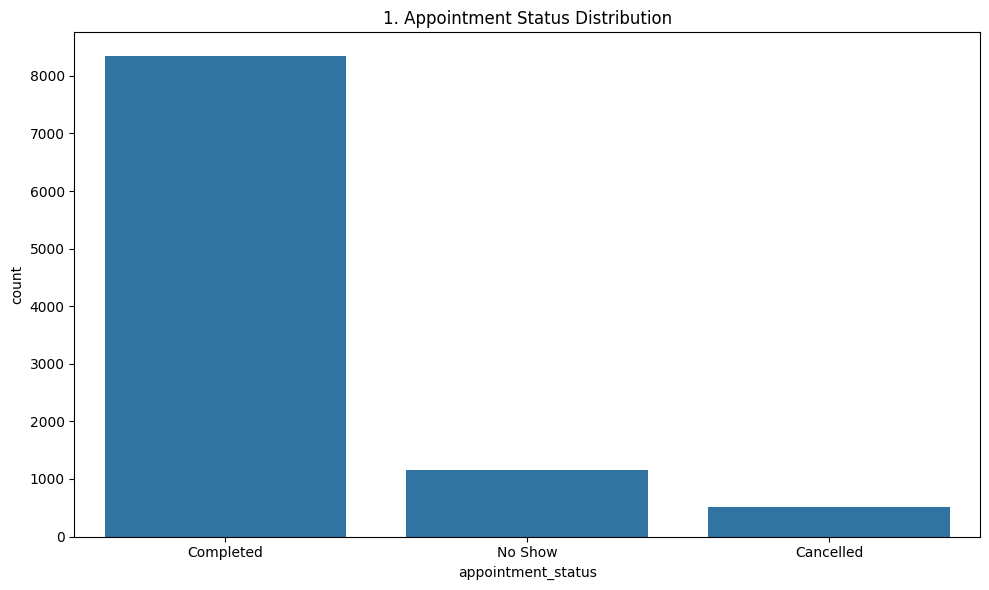

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='appointment_status')
plt.title(f'{plot_no}. Appointment Status Distribution')
show_fig()
plot_no += 1

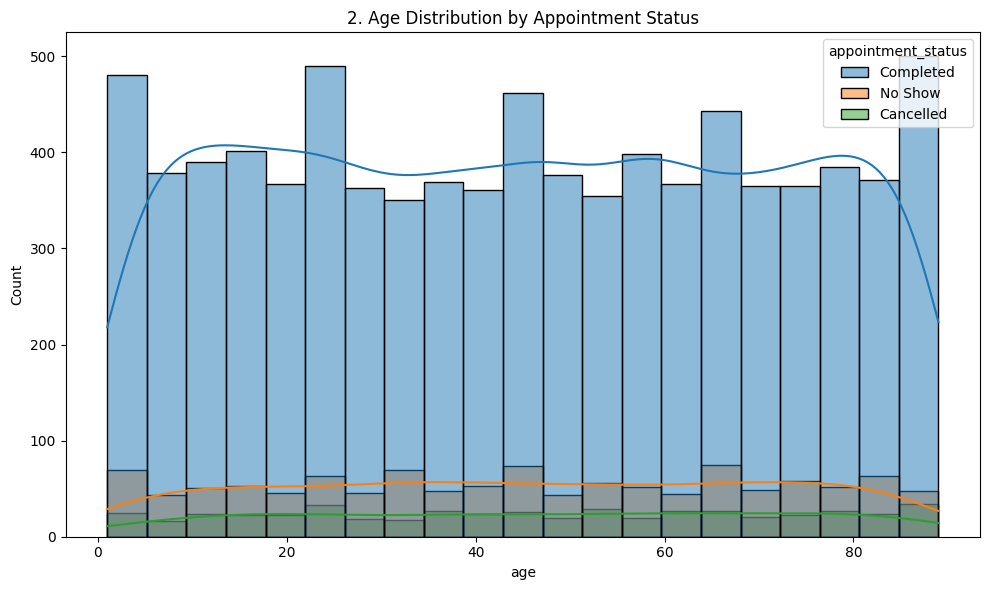

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='appointment_status', kde=True)
plt.title(f'{plot_no}. Age Distribution by Appointment Status')
show_fig()
plot_no += 1

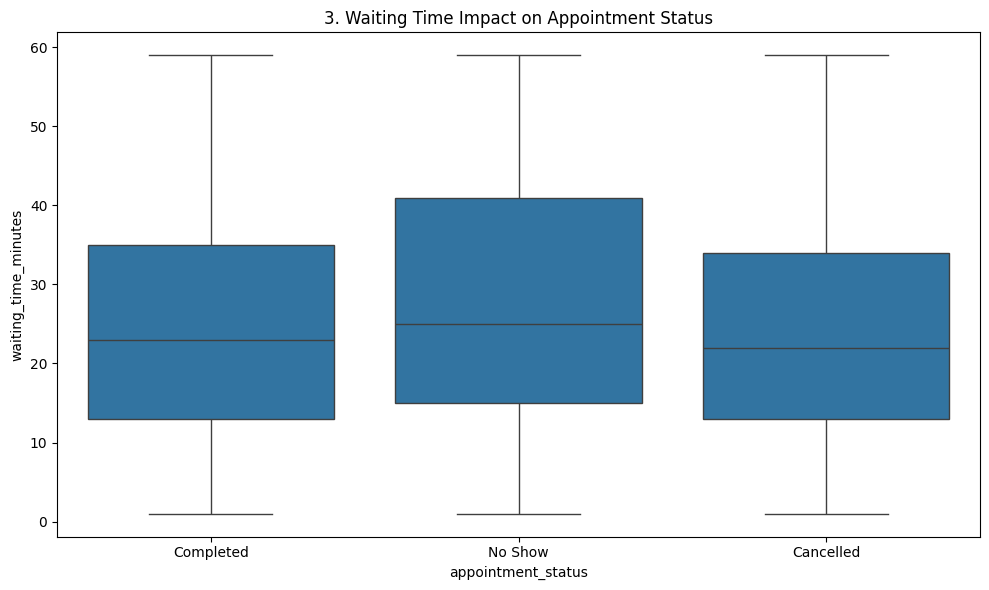

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='waiting_time_minutes')
plt.title(f'{plot_no}. Waiting Time Impact on Appointment Status')
show_fig()
plot_no += 1

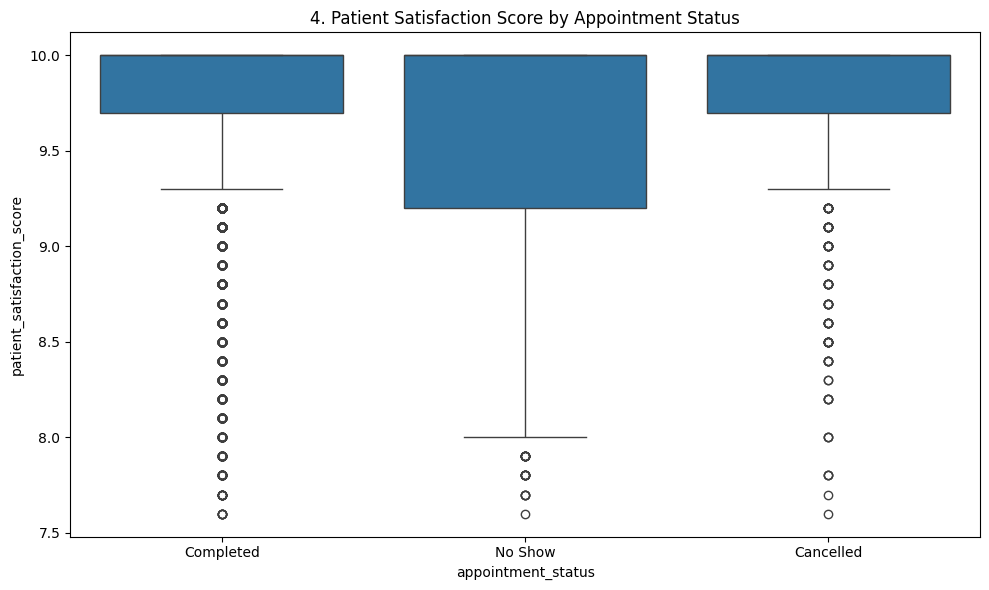

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='patient_satisfaction_score')
plt.title(f'{plot_no}. Patient Satisfaction Score by Appointment Status')
show_fig()
plot_no += 1

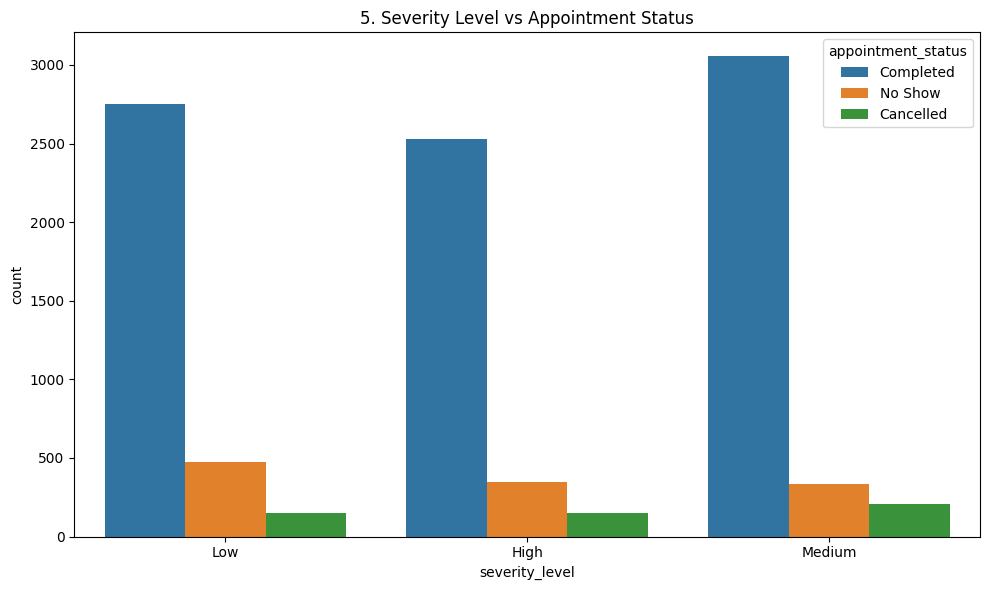

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='severity_level', hue='appointment_status')
plt.title(f'{plot_no}. Severity Level vs Appointment Status')
show_fig()
plot_no += 1

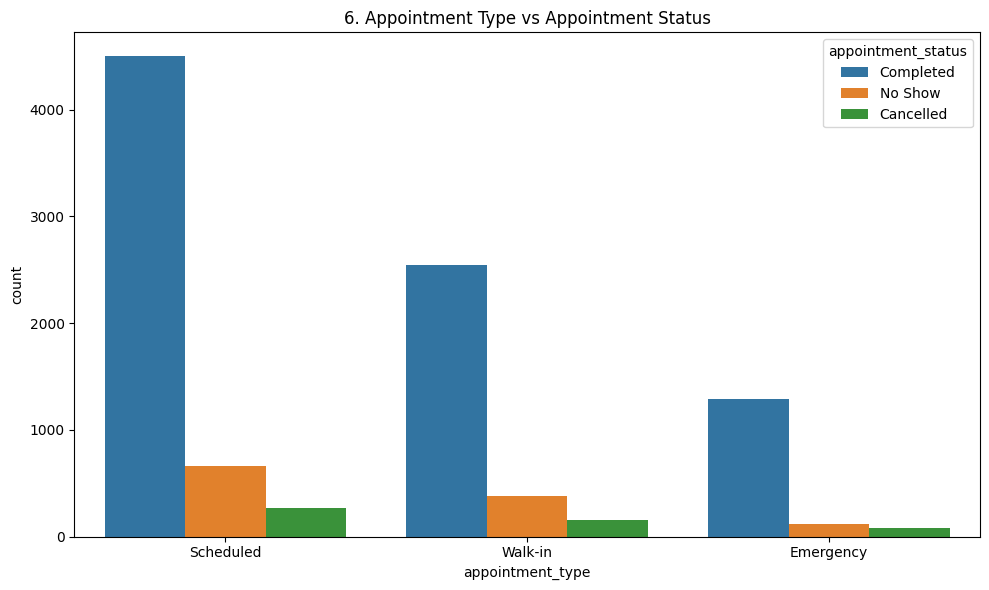

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='appointment_type', hue='appointment_status')
plt.title(f'{plot_no}. Appointment Type vs Appointment Status')
show_fig()
plot_no += 1

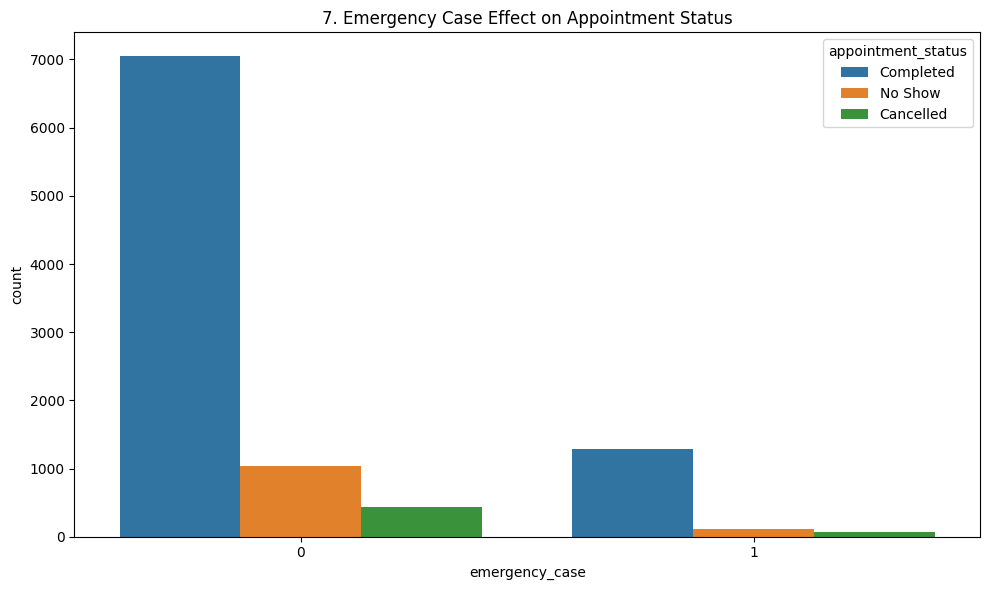

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='emergency_case', hue='appointment_status')
plt.title(f'{plot_no}. Emergency Case Effect on Appointment Status')
show_fig()
plot_no += 1

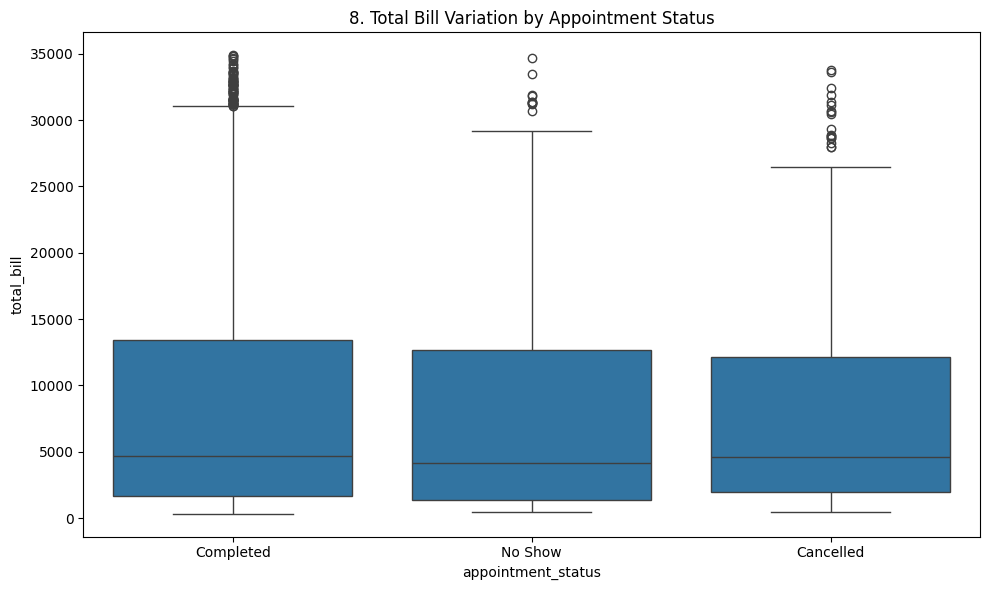

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='total_bill')
plt.title(f'{plot_no}. Total Bill Variation by Appointment Status')
show_fig()
plot_no += 1

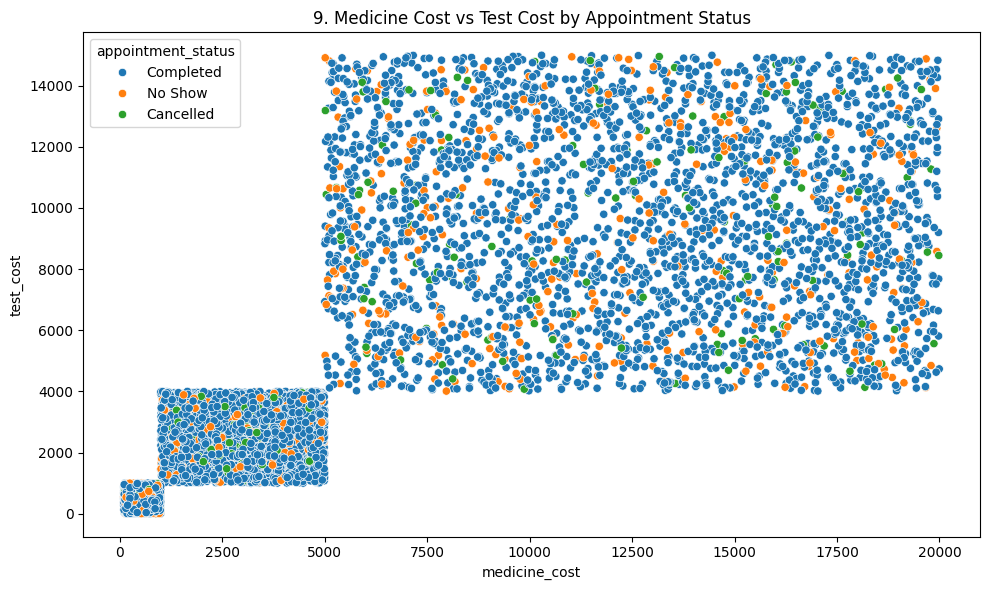

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='medicine_cost', y='test_cost', hue='appointment_status')
plt.title(f'{plot_no}. Medicine Cost vs Test Cost by Appointment Status')
show_fig()
plot_no += 1

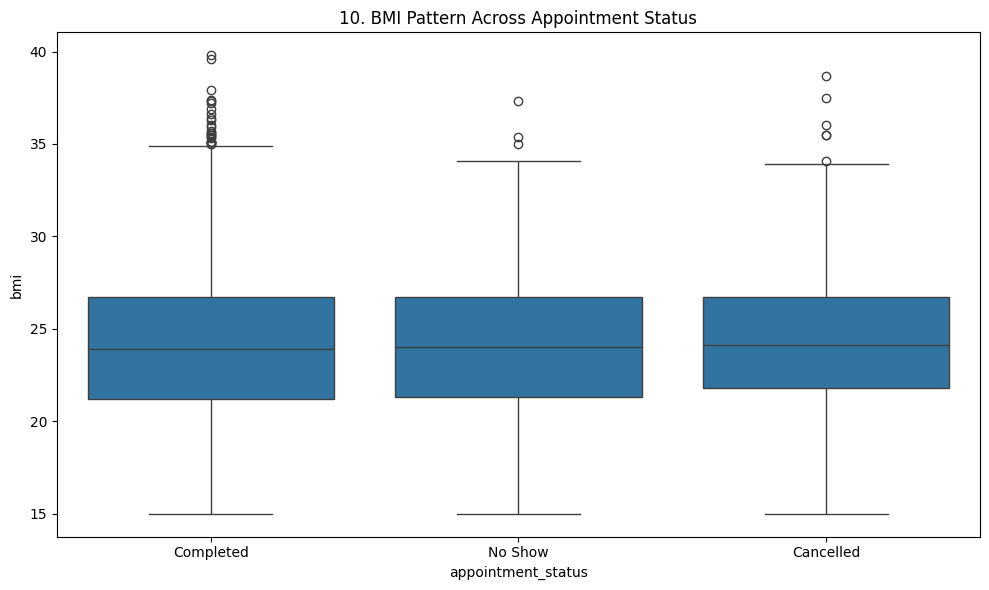

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='bmi')
plt.title(f'{plot_no}. BMI Pattern Across Appointment Status')
show_fig()
plot_no += 1

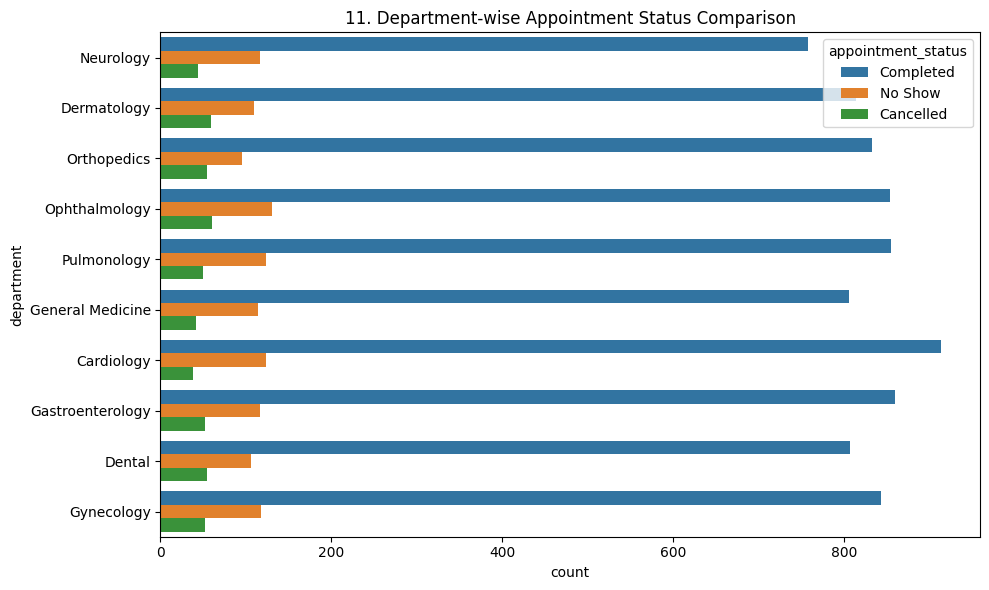

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='department', hue='appointment_status')
plt.title(f'{plot_no}. Department-wise Appointment Status Comparison')
show_fig()
plot_no += 1

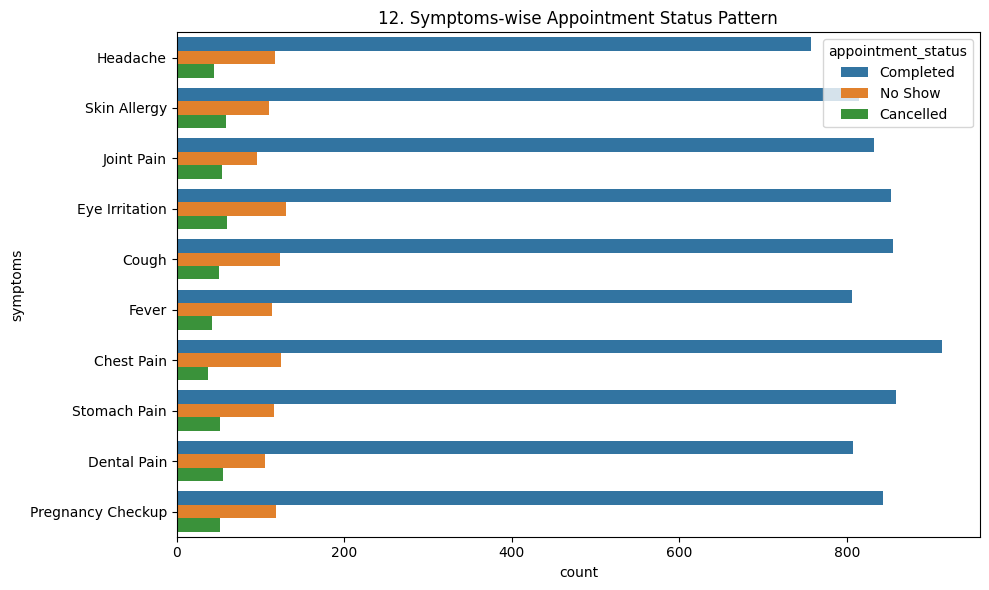

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='symptoms', hue='appointment_status')
plt.title(f'{plot_no}. Symptoms-wise Appointment Status Pattern')
show_fig()
plot_no += 1

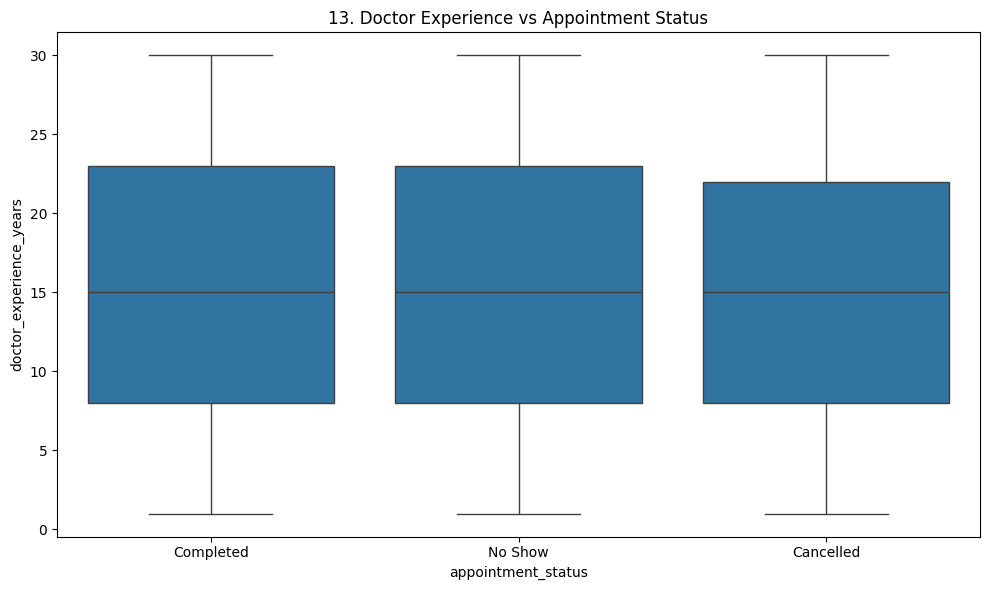

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='doctor_experience_years')
plt.title(f'{plot_no}. Doctor Experience vs Appointment Status')
show_fig()
plot_no += 1

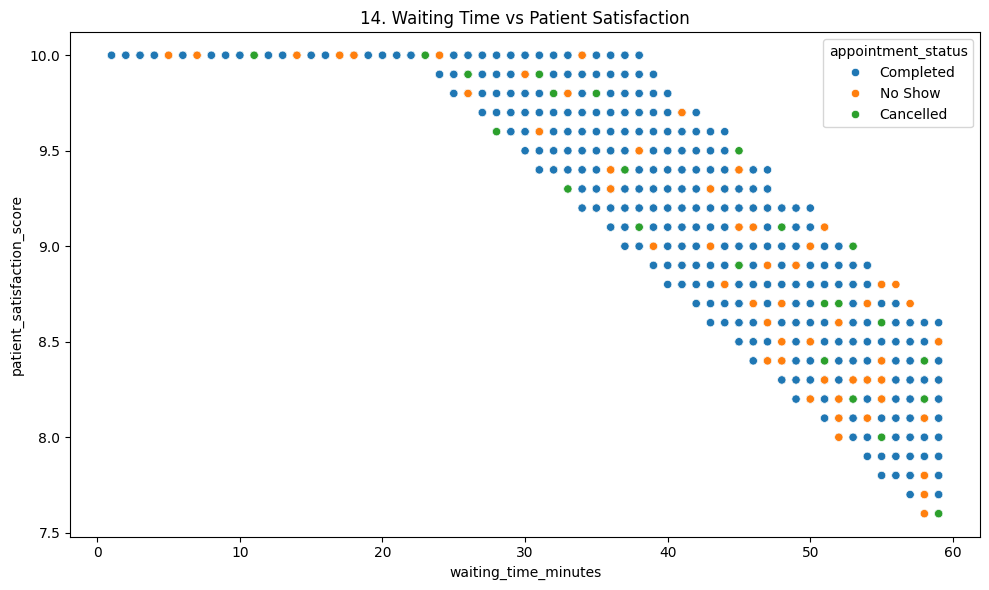

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='waiting_time_minutes', y='patient_satisfaction_score', hue='appointment_status')
plt.title(f'{plot_no}. Waiting Time vs Patient Satisfaction')
show_fig()
plot_no += 1

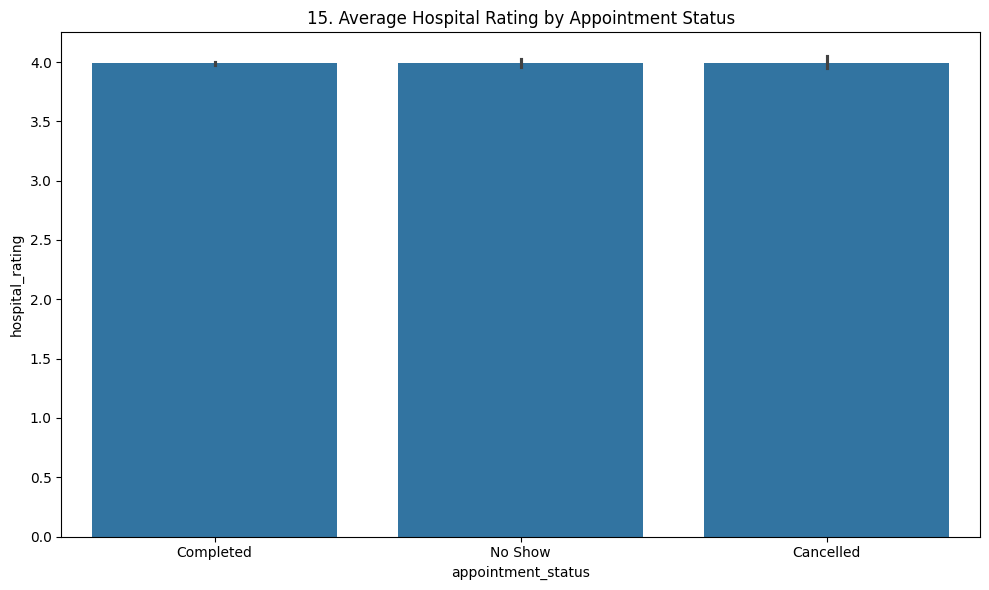

In [28]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='appointment_status', y='hospital_rating')
plt.title(f'{plot_no}. Average Hospital Rating by Appointment Status')
show_fig()
plot_no += 1

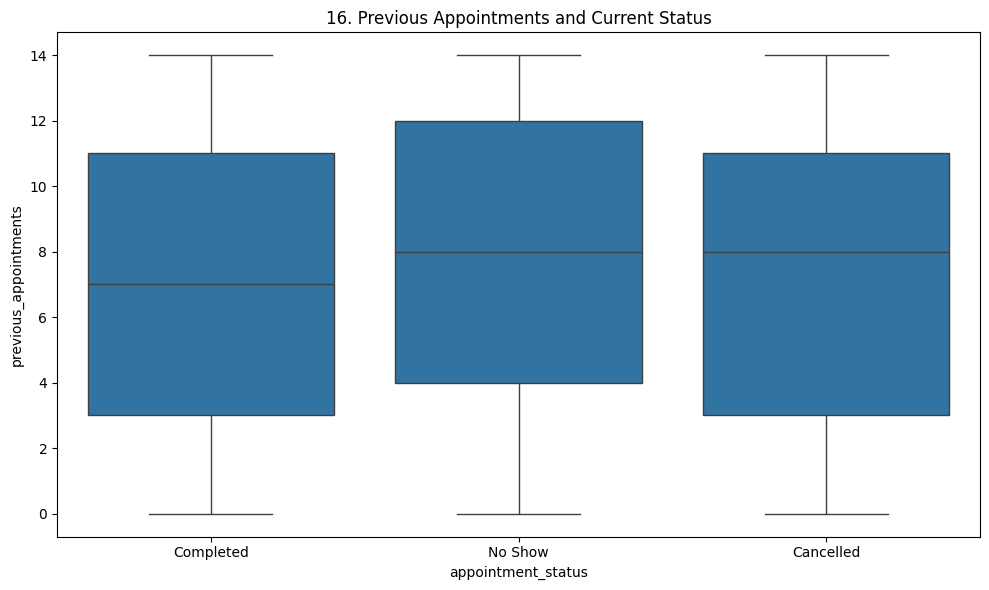

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='previous_appointments')
plt.title(f'{plot_no}. Previous Appointments and Current Status')
show_fig()
plot_no += 1

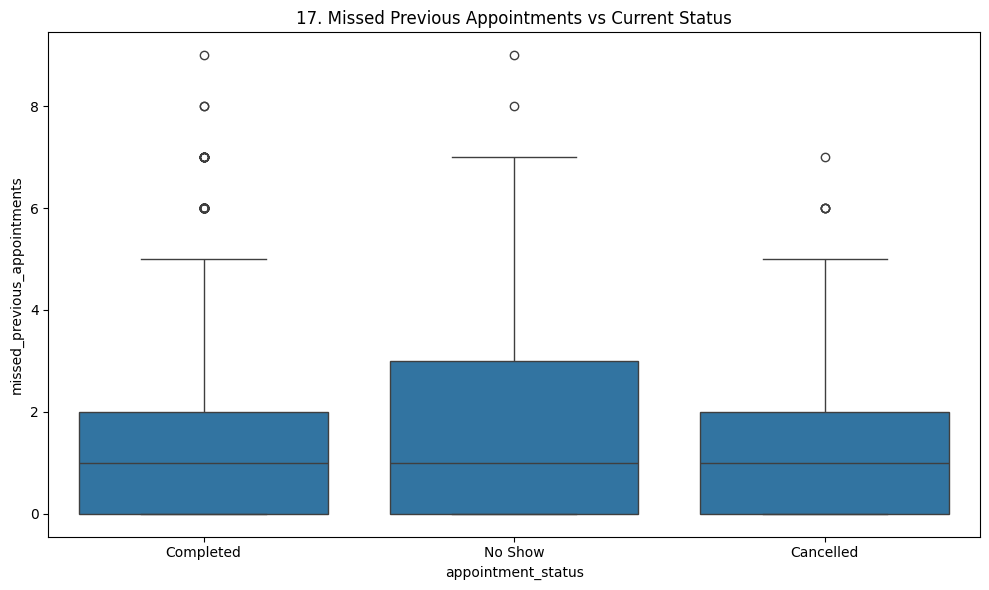

In [30]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='appointment_status', y='missed_previous_appointments')
plt.title(f'{plot_no}. Missed Previous Appointments vs Current Status')
show_fig()
plot_no += 1

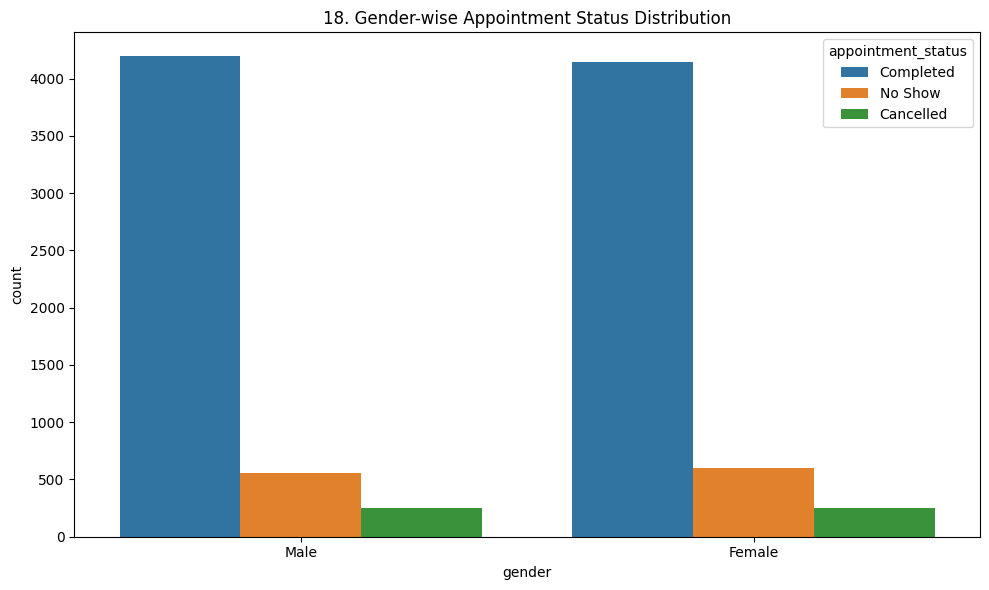

In [31]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='appointment_status')
plt.title(f'{plot_no}. Gender-wise Appointment Status Distribution')
show_fig()
plot_no += 1

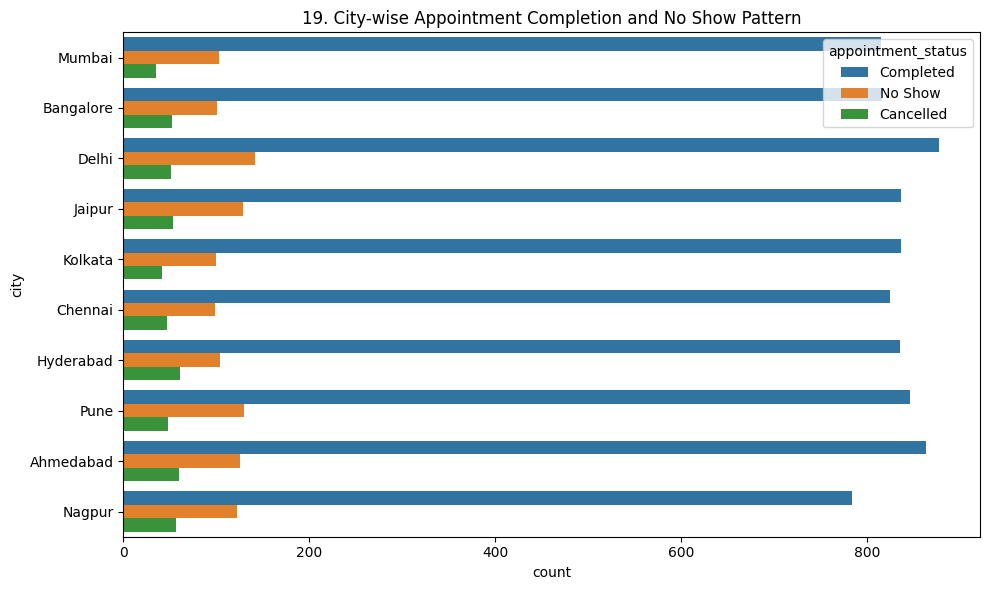

In [32]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, y='city', hue='appointment_status')
plt.title(f'{plot_no}. City-wise Appointment Completion and No Show Pattern')
show_fig()
plot_no += 1

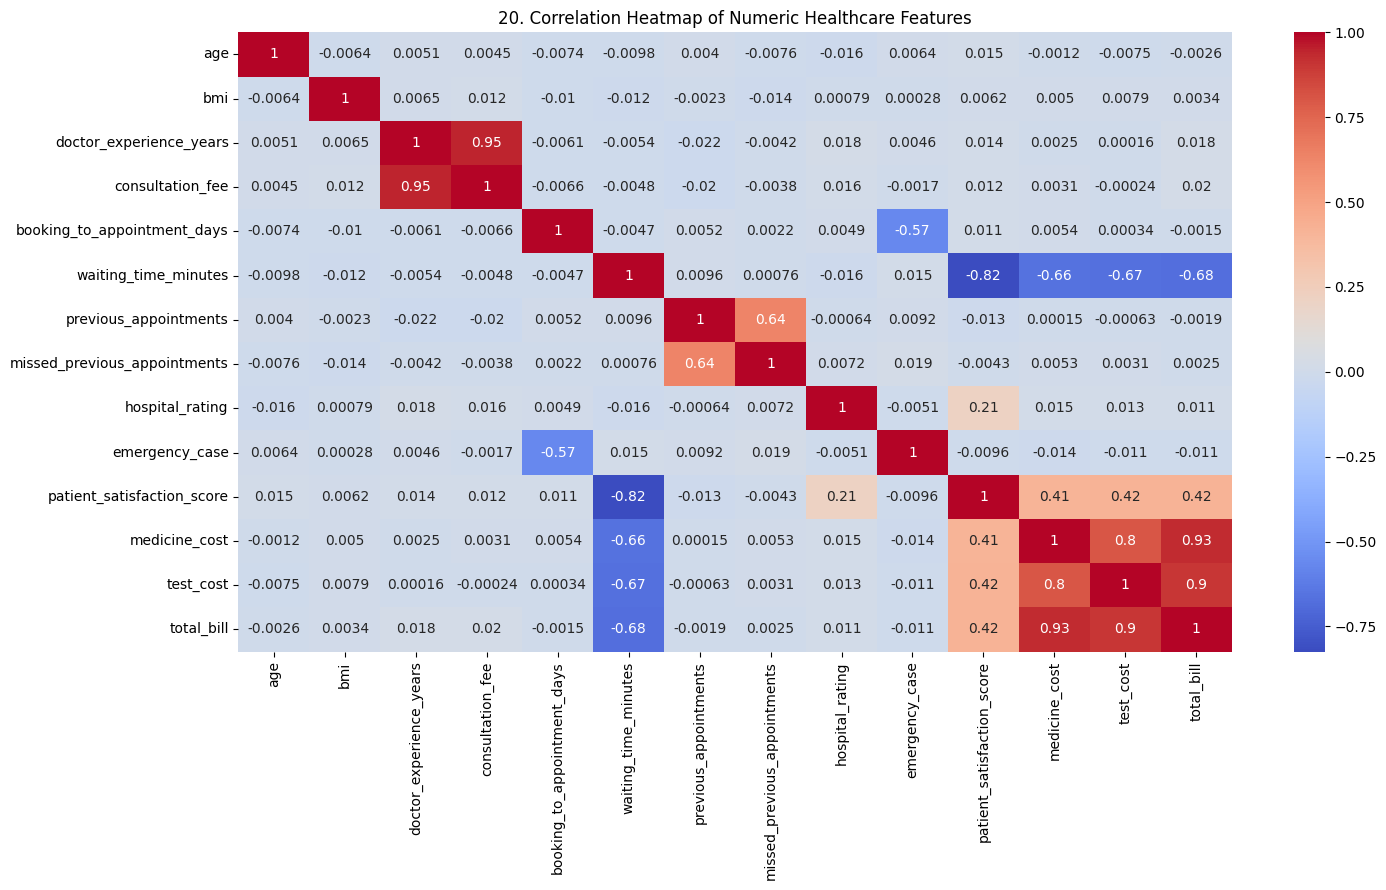

In [33]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Healthcare Features')
show_fig()
plot_no += 1

# Model Training

## Copy dataframe

In [34]:
data = df.copy()

## Drop patient id because it is unique and not useful for prediction

In [35]:
data = data.drop(columns=['patient_id'], errors='ignore')

## Remove missing values

In [36]:
data = data.dropna()

## Separate input features and target column

In [37]:
X = data.drop('appointment_status', axis=1)
y = data['appointment_status']

## Encode target labels

In [38]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

## Select numeric columns

In [39]:
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

## Select categorical columns

In [40]:
categorical_cols = X.select_dtypes(include=['object']).columns

## Create preprocessing for numeric and categorical data

In [41]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

## Split data into train and test parts

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Create supervised machine learning model pipeline

In [43]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ))
])

## Train the model

In [44]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [45]:
y_pred = model.predict(X_test)

## Calculate accuracy score

In [46]:
accuracy = accuracy_score(y_test, y_pred)

## Print accuracy score

In [47]:
print(f"Model Accuracy Score: {accuracy * 100:.2f}%")

Model Accuracy Score: 83.55%


## Print classification report

In [48]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00       101
   Completed       0.84      0.99      0.91      1668
     No Show       0.50      0.06      0.10       231

    accuracy                           0.84      2000
   macro avg       0.45      0.35      0.34      2000
weighted avg       0.76      0.84      0.77      2000



## Create confusion matrix

In [49]:
cm = confusion_matrix(y_test, y_pred)

## Plot confusion matrix

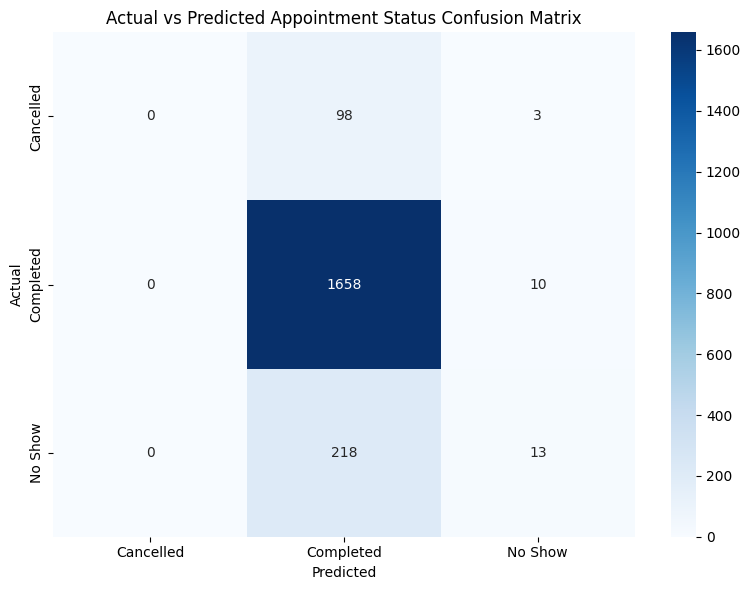

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Actual vs Predicted Appointment Status Confusion Matrix')
plt.tight_layout()
plt.show()